# Diabetes Readmission: Causal Inference

This notebook extends the predictive modeling analysis by asking a causal question.

The goal is to estimate whether receiving diabetes medication changes the probability of 30-day hospital readmission after adjustment for observed pre-treatment confounders.

Because this is observational data, causal interpretation depends on strong assumptions and should be stated cautiously.


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors


## 2. Load the Cleaned Dataset


In [2]:
df = pd.read_csv("diabetes_clean.csv")

print("Shape:", df.shape)
df.head()


Shape: (99340, 47)


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_30d
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,NO,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,...,Up,No,No,No,No,No,Ch,Yes,>30,0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,...,No,No,No,No,No,No,No,Yes,NO,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,...,Up,No,No,No,No,No,Ch,Yes,NO,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,...,Steady,No,No,No,No,No,Ch,Yes,NO,0


## 3. Define the Causal Question

### Research Question

Does receiving diabetes medication affect the probability of 30-day hospital readmission?

### Treatment

- Treated: `diabetesMed == "Yes"`
- Control: `diabetesMed == "No"`

### Outcome

- `readmitted_30d = 1`: readmitted within 30 days
- `readmitted_30d = 0`: not readmitted within 30 days

### Estimand

The primary estimand is the Average Treatment Effect on the Treated (ATT).

This asks: among patients who received diabetes medication, how would their average readmission risk have differed if they had not received diabetes medication?


## 4. Causal Assumptions

This analysis relies on the following assumptions:

1. **Consistency**: observed outcomes correspond to the treatment actually received.
2. **Conditional exchangeability**: after adjustment, no unmeasured confounders jointly affect treatment and readmission.
3. **Positivity**: patients with similar covariates have a positive probability of receiving either treatment level.
4. **No interference**: one patient's treatment does not affect another patient's outcome.
5. **Correct temporal ordering**: adjustment variables occur before treatment and are not consequences of treatment.

These assumptions cannot be fully verified from the dataset.


## 5. Define Treatment and Outcome


In [3]:
analysis_df = df.copy()

# Define binary treatment and outcome variables
analysis_df["treatment"] = (analysis_df["diabetesMed"] == "Yes").astype(int)
analysis_df["outcome"] = analysis_df["readmitted_30d"].astype(int)

print("Treatment distribution:")
display(analysis_df["treatment"].value_counts().to_frame("count"))

print("Outcome distribution:")
display(analysis_df["outcome"].value_counts().to_frame("count"))


Treatment distribution:


,count
treatment,
1,76717
0,22623


Outcome distribution:


,count
outcome,
0,88026
1,11314


## 6. Restrict to One Encounter per Patient

To reduce dependence from repeated encounters, keep the first observed encounter for each patient.


In [4]:
analysis_df = (
    analysis_df
    .sort_values("encounter_id")
    # Keep one encounter per patient to reduce within-patient dependence
    .drop_duplicates(subset="patient_nbr", keep="first")
    .copy()
)

print("Unique patients:", analysis_df["patient_nbr"].nunique())
print("Rows in analysis dataset:", len(analysis_df))


Unique patients: 69987
Rows in analysis dataset: 69987


## 7. Select Pre-Treatment Confounders

The adjustment set should include variables that plausibly affect both treatment assignment and readmission, while excluding treatment descendants, the outcome, and identifiers.

The initial adjustment set focuses on demographics, prior healthcare utilization, and admission characteristics.


In [5]:
candidate_confounders = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "admission_source_id",
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

confounders = [c for c in candidate_confounders if c in analysis_df.columns]

print("Confounders used:")
for c in confounders:
    print("-", c)


Confounders used:
- race
- gender
- age
- admission_type_id
- admission_source_id
- number_outpatient
- number_emergency
- number_inpatient


## 8. Compare Treated and Control Groups Before Adjustment


In [6]:
raw_summary = (
    analysis_df
    .groupby("treatment")["outcome"]
    .agg(["count", "mean"])
    .rename(index={0: "Control", 1: "Treated"})
)

raw_summary["mean"] = raw_summary["mean"].round(4)
display(raw_summary)

raw_difference = (
    analysis_df.loc[analysis_df["treatment"] == 1, "outcome"].mean()
    - analysis_df.loc[analysis_df["treatment"] == 0, "outcome"].mean()
)

print("Unadjusted risk difference:", round(raw_difference, 4))


,count,mean
treatment,,
Control,16685,0.0756
Treated,53302,0.0942


Unadjusted risk difference: 0.0186


The unadjusted difference is descriptive only and should not be interpreted causally because treated and untreated patients may differ systematically before treatment.


### Result Summary

Before adjustment, the 30-day readmission rate was **9.42%** in the treated group and **7.56%** in the control group. The unadjusted risk difference was therefore **+1.86 percentage points**.

This is a descriptive comparison only. Patients who received diabetes medication may differ from untreated patients in ways that also affect readmission risk, so the raw difference should not be interpreted as a treatment effect.


## 9. Prepare Covariates for Propensity Score Modeling


In [7]:
X = analysis_df[confounders].copy()
treatment = analysis_df["treatment"]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


## 10. Estimate Propensity Scores


In [8]:
propensity_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]
)

# Estimate the probability of receiving diabetes medication from observed confounders
propensity_model.fit(X, treatment)

analysis_df["propensity_score"] = propensity_model.predict_proba(X)[:, 1]

analysis_df["propensity_score"].describe()


count    69987.000000
mean         0.761656
std          0.031314
min          0.626233
25%          0.746461
50%          0.761077
75%          0.774996
max          0.999779
Name: propensity_score, dtype: float64

## 11. Check Propensity Score Overlap


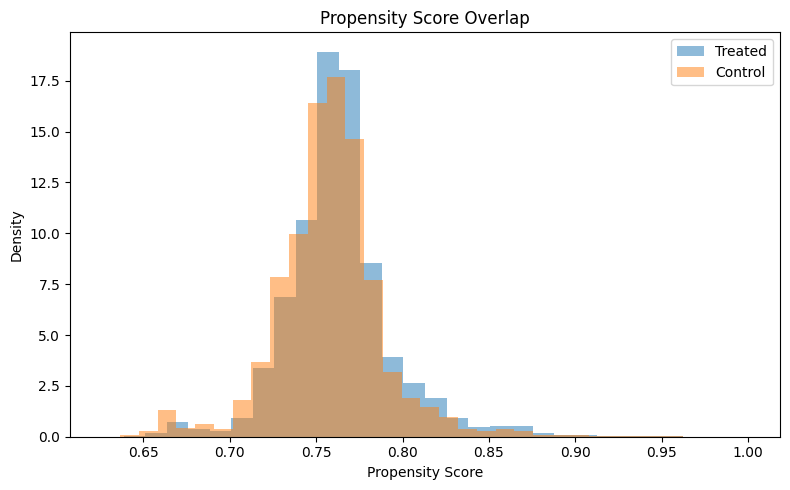

In [9]:
treated_scores = analysis_df.loc[
    analysis_df["treatment"] == 1,
    "propensity_score"
]

control_scores = analysis_df.loc[
    analysis_df["treatment"] == 0,
    "propensity_score"
]

plt.figure(figsize=(8, 5))

plt.hist(
    treated_scores,
    bins=30,
    alpha=0.5,
    density=True,
    label="Treated"
)

plt.hist(
    control_scores,
    bins=30,
    alpha=0.5,
    density=True,
    label="Control"
)

plt.xlabel("Propensity Score")
plt.ylabel("Density")
plt.title("Propensity Score Overlap")
plt.legend()
plt.tight_layout()
plt.show()


Adequate overlap is needed for valid comparison. Large regions with only treated or only control patients indicate a positivity problem.


### Result Summary

Estimated propensity scores ranged from approximately **0.626 to 0.9998**, with a median of about **0.761**. The treated and control distributions showed substantial overlap across most of the observed range, although a small group of treated patients had very high treatment probabilities with fewer comparable controls.

Overall, the overlap appears sufficient for the primary analysis, but the high-score tail motivates checking extreme weights and performing a trimming sensitivity analysis.


## 12. Inverse Probability Weighting for the ATT


In [10]:
eps = 1e-6

analysis_df["propensity_score_clipped"] = (
    analysis_df["propensity_score"].clip(eps, 1 - eps)
)

# ATT weighting keeps treated patients at weight 1 and reweights controls to resemble them
analysis_df["att_weight"] = np.where(
    analysis_df["treatment"] == 1,
    1.0,
    analysis_df["propensity_score_clipped"]
    / (1 - analysis_df["propensity_score_clipped"])
)

analysis_df.groupby("treatment")["att_weight"].describe()


,count,mean,std,min,25%,50%,75%,max
treatment,,,,,,,,
0,16685.0,3.20325,0.726008,1.751115,2.871727,3.138723,3.34906,25.650878
1,53302.0,1.00000,0.000000,1.000000,1.000000,1.000000,1.00000,1.000000


## 13. Covariate Balance Before and After Weighting

Propensity score adjustment should make the treated and control groups more similar with respect to observed confounders.

Covariate balance is evaluated using the standardized mean difference (SMD). Absolute SMD values below approximately 0.10 are commonly considered evidence of acceptable balance.

Categorical variables are converted to indicator variables so that each category can be assessed separately.


In [11]:
# Create a balance matrix using the same observed confounders
balance_data = analysis_df[confounders].copy()

for column in balance_data.select_dtypes(include=["number"]).columns:
    balance_data[column] = balance_data[column].fillna(
        balance_data[column].median()
    )

for column in balance_data.select_dtypes(exclude=["number"]).columns:
    balance_data[column] = balance_data[column].fillna("Missing")

balance_matrix = pd.get_dummies(
    balance_data,
    drop_first=False,
    dtype=float
)

print("Balance variables after encoding:", balance_matrix.shape[1])


Balance variables after encoding: 23


In [12]:
def weighted_mean(x, w):
    return np.sum(w * x) / np.sum(w)


def weighted_variance(x, w):
    mean = weighted_mean(x, w)
    return np.sum(w * (x - mean) ** 2) / np.sum(w)


def calculate_smd(x, treatment, weights=None):
    x = np.asarray(x, dtype=float)
    treatment = np.asarray(treatment)

    if weights is None:
        weights = np.ones(len(x))
    else:
        weights = np.asarray(weights, dtype=float)

    treated_mask = treatment == 1
    control_mask = treatment == 0

    treated_mean = weighted_mean(
        x[treated_mask],
        weights[treated_mask]
    )
    control_mean = weighted_mean(
        x[control_mask],
        weights[control_mask]
    )

    treated_var = weighted_variance(
        x[treated_mask],
        weights[treated_mask]
    )
    control_var = weighted_variance(
        x[control_mask],
        weights[control_mask]
    )

    pooled_sd = np.sqrt((treated_var + control_var) / 2)

    if pooled_sd == 0:
        return 0.0

    return (treated_mean - control_mean) / pooled_sd


In [13]:
balance_results = []

treatment_values = analysis_df["treatment"].to_numpy()
att_weights = analysis_df["att_weight"].to_numpy()

for column in balance_matrix.columns:
    values = balance_matrix[column].to_numpy()

    smd_before = calculate_smd(
        values,
        treatment_values
    )

    smd_after = calculate_smd(
        values,
        treatment_values,
        weights=att_weights
    )

    balance_results.append({
        "Covariate": column,
        "SMD Before": smd_before,
        "SMD After IPW": smd_after
    })

balance_df = pd.DataFrame(balance_results)
balance_df["Abs SMD Before"] = balance_df["SMD Before"].abs()
balance_df["Abs SMD After IPW"] = balance_df["SMD After IPW"].abs()

balance_df = balance_df.sort_values(
    "Abs SMD Before",
    ascending=False
)

display(balance_df.round(3))

print(
    "Maximum absolute SMD before weighting:",
    round(balance_df["Abs SMD Before"].max(), 3)
)
print(
    "Maximum absolute SMD after weighting:",
    round(balance_df["Abs SMD After IPW"].max(), 3)
)
print(
    "Covariates above 0.10 before weighting:",
    int((balance_df["Abs SMD Before"] >= 0.10).sum())
)
print(
    "Covariates above 0.10 after weighting:",
    int((balance_df["Abs SMD After IPW"] >= 0.10).sum())
)


,Covariate,SMD Before,SMD After IPW,Abs SMD Before,Abs SMD After IPW
3,number_emergency,0.073,-0.028,0.073,0.028
22,age_[90-100),-0.069,0.002,0.069,0.002
2,number_outpatient,0.065,-0.021,0.065,0.021
4,number_inpatient,0.063,-0.009,0.063,0.009
14,age_[10-20),0.054,-0.003,0.054,0.003
21,age_[80-90),-0.051,0.003,0.051,0.003
10,race_Unknown,0.049,-0.001,0.049,0.001
19,age_[60-70),0.046,-0.003,0.046,0.003
11,gender_Female,-0.045,0.003,0.045,0.003
12,gender_Male,0.045,-0.003,0.045,0.003


Maximum absolute SMD before weighting: 0.073
Maximum absolute SMD after weighting: 0.028
Covariates above 0.10 before weighting: 0
Covariates above 0.10 after weighting: 0


### Love Plot

The love plot compares absolute standardized mean differences before and after weighting. Points closer to zero indicate better covariate balance.


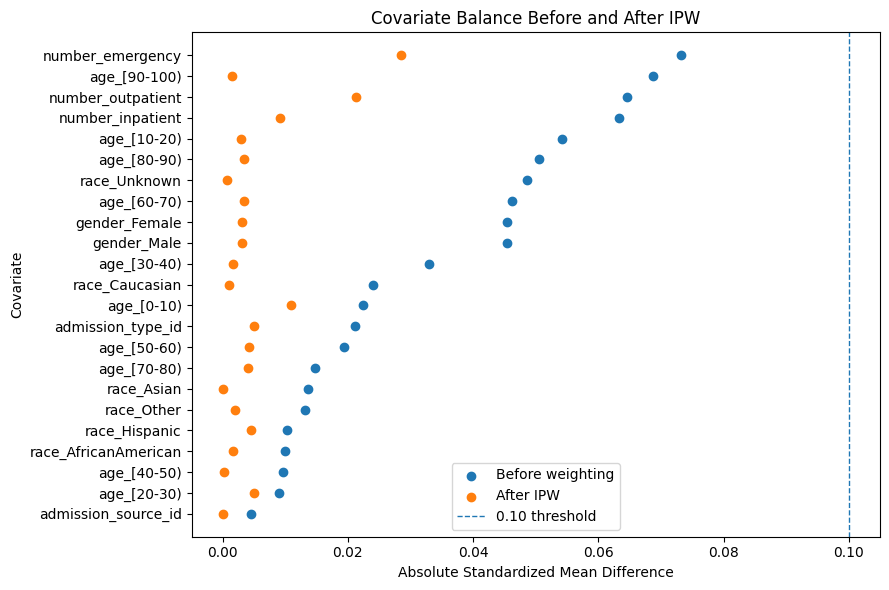

In [14]:
plot_balance = (
    balance_df
    .sort_values("Abs SMD Before", ascending=True)
    .copy()
)

plt.figure(figsize=(9, max(6, len(plot_balance) * 0.25)))

plt.scatter(
    plot_balance["Abs SMD Before"],
    plot_balance["Covariate"],
    label="Before weighting"
)

plt.scatter(
    plot_balance["Abs SMD After IPW"],
    plot_balance["Covariate"],
    label="After IPW"
)

plt.axvline(
    0.10,
    linestyle="--",
    linewidth=1,
    label="0.10 threshold"
)

plt.xlabel("Absolute Standardized Mean Difference")
plt.ylabel("Covariate")
plt.title("Covariate Balance Before and After IPW")
plt.legend()
plt.tight_layout()
plt.show()


### Balance Interpretation

Weighting is considered successful when the absolute SMDs decrease substantially and are generally below 0.10 after weighting. If important covariates remain imbalanced, the propensity score model may need to be modified before interpreting the ATT estimate causally.


### Result Summary

The treated and control groups were already reasonably balanced on the measured confounders before adjustment. The largest absolute standardized mean difference was approximately **0.073**, and **no measured covariate exceeded the 0.10 threshold**.

This indicates that severe measured confounding was not present in the selected adjustment variables, although small differences remained and unmeasured confounding is still possible.


## 14. Inspect Extreme Weights


In [15]:
analysis_df["att_weight"].describe(
    percentiles=[0.90, 0.95, 0.99]
)


count    69987.000000
mean         1.525258
std          1.003516
min          1.000000
90%          3.199602
95%          3.439163
99%          4.308767
max         25.650878
Name: att_weight, dtype: float64

Extreme weights can make the estimate unstable. If many large weights are present, trimming or truncation should be considered as a sensitivity analysis.


## 15. Estimate the ATT Using IPW


In [16]:
treated = analysis_df[analysis_df["treatment"] == 1]
control = analysis_df[analysis_df["treatment"] == 0]

treated_risk = np.average(
    treated["outcome"],
    weights=treated["att_weight"]
)

weighted_control_risk = np.average(
    control["outcome"],
    weights=control["att_weight"]
)

# Estimate the ATT as the treated risk minus the weighted counterfactual control risk
att_ipw = treated_risk - weighted_control_risk

print("Observed treated risk:", round(treated_risk, 4))
print("Weighted control risk:", round(weighted_control_risk, 4))
print("IPW ATT risk difference:", round(att_ipw, 4))


Observed treated risk: 0.0942
Weighted control risk: 0.0786
IPW ATT risk difference: 0.0156


The ATT is an absolute risk difference.

For example, an ATT of `-0.03` would represent an estimated 3 percentage point lower 30-day readmission risk among treated patients under treatment compared with their estimated counterfactual risk without treatment.


## 16. Bootstrap Confidence Interval for the IPW ATT


In [17]:
def estimate_att_ipw(data):
    treated = data[data["treatment"] == 1]
    control = data[data["treatment"] == 0]

    if len(treated) == 0 or len(control) == 0:
        return np.nan

    treated_risk = np.average(
        treated["outcome"],
        weights=treated["att_weight"]
    )

    control_risk = np.average(
        control["outcome"],
        weights=control["att_weight"]
    )

    return treated_risk - control_risk


rng = np.random.default_rng(42)
bootstrap_estimates = []

# Bootstrap the patient-level analysis dataset to quantify uncertainty
for _ in range(1000):
    sample_idx = rng.integers(
        0,
        len(analysis_df),
        len(analysis_df)
    )

    sample = analysis_df.iloc[sample_idx]
    estimate = estimate_att_ipw(sample)

    if not np.isnan(estimate):
        bootstrap_estimates.append(estimate)

ci_lower, ci_upper = np.percentile(
    bootstrap_estimates,
    [2.5, 97.5]
)

print("IPW ATT:", round(att_ipw, 4))
print(
    "95% bootstrap CI:",
    (round(ci_lower, 4), round(ci_upper, 4))
)


IPW ATT: 0.0156
95% bootstrap CI: (0.0106, 0.0206)


## 17. Propensity Score Matching


In [18]:
treated_df = analysis_df[
    analysis_df["treatment"] == 1
].copy()

control_df = analysis_df[
    analysis_df["treatment"] == 0
].copy()

nn = NearestNeighbors(
    n_neighbors=1,
    metric="euclidean"
)

# Match each treated patient to the nearest control by propensity score
nn.fit(control_df[["propensity_score"]])

distances, indices = nn.kneighbors(
    treated_df[["propensity_score"]]
)

matched_control_df = (
    control_df
    .iloc[indices.flatten()]
    .copy()
    .reset_index(drop=True)
)

matched_treated_df = treated_df.reset_index(drop=True)

matched_pairs = pd.DataFrame({
    "treated_outcome": matched_treated_df["outcome"],
    "control_outcome": matched_control_df["outcome"],
    "treated_ps": matched_treated_df["propensity_score"],
    "control_ps": matched_control_df["propensity_score"],
    "distance": distances.flatten()
})

matched_pairs.head()


,treated_outcome,control_outcome,treated_ps,control_ps,distance
0,0,0,0.721269,0.721269,0.0
1,0,0,0.658474,0.658474,0.0
2,0,0,0.756594,0.756594,0.0
3,0,0,0.747252,0.747252,0.0
4,0,0,0.764923,0.764923,0.0


## 18. Estimate the ATT Using Matching


In [19]:
# Estimate the matched ATT as the difference in mean outcomes within matched pairs
att_matching = (
    matched_pairs["treated_outcome"].mean()
    - matched_pairs["control_outcome"].mean()
)

print("Matching ATT risk difference:", round(att_matching, 4))
print(
    "Mean propensity score distance:",
    round(matched_pairs["distance"].mean(), 4)
)


Matching ATT risk difference: 0.022
Mean propensity score distance: 0.0


## 19. Covariate Balance After Propensity Score Matching

Balance should also be checked in the matched sample. The same standardized mean difference threshold of approximately 0.10 is used.


In [20]:
# Reconstruct confounder values for matched treated and control patients
matched_treated_covariates = balance_matrix.loc[
    matched_treated_df.index.map(
        lambda i: matched_treated_df.loc[i].name
    )
] if False else None

# Use the original row indices retained before resetting indices
matched_treated_original = treated_df.copy()
matched_control_original = control_df.iloc[indices.flatten()].copy()

matched_treated_balance = balance_matrix.loc[
    matched_treated_original.index
].reset_index(drop=True)

matched_control_balance = balance_matrix.loc[
    matched_control_original.index
].reset_index(drop=True)

matching_balance_results = []

for column in balance_matrix.columns:
    treated_values = matched_treated_balance[column].to_numpy()
    control_values = matched_control_balance[column].to_numpy()

    treated_mean = treated_values.mean()
    control_mean = control_values.mean()
    pooled_sd = np.sqrt(
        (treated_values.var(ddof=0) + control_values.var(ddof=0)) / 2
    )

    if pooled_sd == 0:
        smd = 0.0
    else:
        smd = (treated_mean - control_mean) / pooled_sd

    matching_balance_results.append({
        "Covariate": column,
        "SMD After Matching": smd
    })

matching_balance_df = pd.DataFrame(matching_balance_results)
matching_balance_df["Abs SMD After Matching"] = (
    matching_balance_df["SMD After Matching"].abs()
)

matching_balance_df = matching_balance_df.sort_values(
    "Abs SMD After Matching",
    ascending=False
)

display(matching_balance_df.round(3))

print(
    "Maximum absolute SMD after matching:",
    round(matching_balance_df["Abs SMD After Matching"].max(), 3)
)
print(
    "Covariates above 0.10 after matching:",
    int((matching_balance_df["Abs SMD After Matching"] >= 0.10).sum())
)


,Covariate,SMD After Matching,Abs SMD After Matching
2,number_outpatient,0.021,0.021
0,admission_type_id,0.019,0.019
3,number_emergency,0.017,0.017
22,age_[90-100),0.015,0.015
18,age_[50-60),-0.013,0.013
19,age_[60-70),-0.012,0.012
4,number_inpatient,0.012,0.012
10,race_Unknown,-0.011,0.011
15,age_[20-30),-0.009,0.009
21,age_[80-90),0.008,0.008


Maximum absolute SMD after matching: 0.021
Covariates above 0.10 after matching: 0


### Combined Balance Comparison

This table compares balance before adjustment, after inverse probability weighting, and after propensity score matching.


In [21]:
combined_balance = (
    balance_df[[
        "Covariate",
        "SMD Before",
        "SMD After IPW"
    ]]
    .merge(
        matching_balance_df[[
            "Covariate",
            "SMD After Matching"
        ]],
        on="Covariate",
        how="left"
    )
)

combined_balance["Abs SMD Before"] = combined_balance["SMD Before"].abs()
combined_balance["Abs SMD After IPW"] = combined_balance["SMD After IPW"].abs()
combined_balance["Abs SMD After Matching"] = combined_balance[
    "SMD After Matching"
].abs()

display(
    combined_balance.sort_values(
        "Abs SMD Before",
        ascending=False
    ).round(3)
)


,Covariate,SMD Before,SMD After IPW,SMD After Matching,Abs SMD Before,Abs SMD After IPW,Abs SMD After Matching
0,number_emergency,0.073,-0.028,0.017,0.073,0.028,0.017
1,age_[90-100),-0.069,0.002,0.015,0.069,0.002,0.015
2,number_outpatient,0.065,-0.021,0.021,0.065,0.021,0.021
3,number_inpatient,0.063,-0.009,0.012,0.063,0.009,0.012
4,age_[10-20),0.054,-0.003,0.004,0.054,0.003,0.004
5,age_[80-90),-0.051,0.003,0.008,0.051,0.003,0.008
6,race_Unknown,0.049,-0.001,-0.011,0.049,0.001,0.011
7,age_[60-70),0.046,-0.003,-0.012,0.046,0.003,0.012
8,gender_Female,-0.045,0.003,0.004,0.045,0.003,0.004
9,gender_Male,0.045,-0.003,-0.004,0.045,0.003,0.004


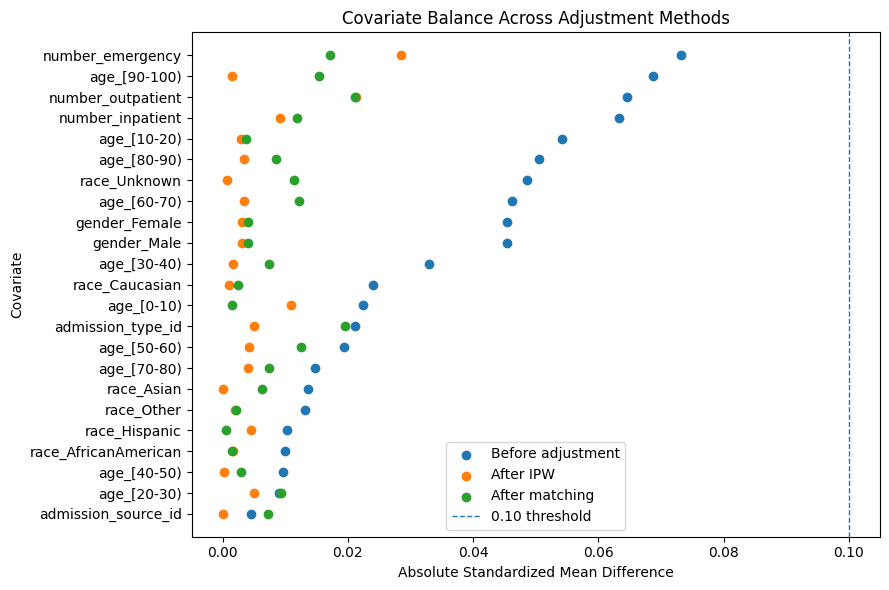

In [22]:
plot_combined = combined_balance.sort_values(
    "Abs SMD Before",
    ascending=True
)

plt.figure(figsize=(9, max(6, len(plot_combined) * 0.25)))

plt.scatter(
    plot_combined["Abs SMD Before"],
    plot_combined["Covariate"],
    label="Before adjustment"
)

plt.scatter(
    plot_combined["Abs SMD After IPW"],
    plot_combined["Covariate"],
    label="After IPW"
)

plt.scatter(
    plot_combined["Abs SMD After Matching"],
    plot_combined["Covariate"],
    label="After matching"
)

plt.axvline(
    0.10,
    linestyle="--",
    linewidth=1,
    label="0.10 threshold"
)

plt.xlabel("Absolute Standardized Mean Difference")
plt.ylabel("Covariate")
plt.title("Covariate Balance Across Adjustment Methods")
plt.legend()
plt.tight_layout()
plt.show()


### Result Summary

Inverse probability weighting further improved measured covariate balance. The maximum absolute standardized mean difference decreased from approximately **0.073 before adjustment to 0.028 after weighting**, with **all measured covariates remaining below 0.10**.

This provides evidence that the ATT weights successfully made the weighted control group resemble the treated group with respect to the observed adjustment variables.


## 20. Compare Causal Estimates


In [23]:
causal_results = pd.DataFrame({
    "Method": [
        "Unadjusted",
        "IPW ATT",
        "Propensity Score Matching ATT"
    ],
    "Risk Difference": [
        raw_difference,
        att_ipw,
        att_matching
    ]
})

causal_results["Risk Difference"] = (
    causal_results["Risk Difference"].round(4)
)

display(causal_results)


,Method,Risk Difference
0,Unadjusted,0.0186
1,IPW ATT,0.0156
2,Propensity Score Matching ATT,0.0220


## 21. Sensitivity Analysis: Trim Extreme Propensity Scores


In [24]:
trimmed_df = analysis_df[
    (analysis_df["propensity_score"] >= 0.05)
    & (analysis_df["propensity_score"] <= 0.95)
].copy()

trimmed_treated = trimmed_df[
    trimmed_df["treatment"] == 1
]

trimmed_control = trimmed_df[
    trimmed_df["treatment"] == 0
]

trimmed_treated_risk = np.average(
    trimmed_treated["outcome"],
    weights=trimmed_treated["att_weight"]
)

trimmed_control_risk = np.average(
    trimmed_control["outcome"],
    weights=trimmed_control["att_weight"]
)

trimmed_att = (
    trimmed_treated_risk
    - trimmed_control_risk
)

print("Rows before trimming:", len(analysis_df))
print("Rows after trimming:", len(trimmed_df))
print("Trimmed IPW ATT:", round(trimmed_att, 4))


Rows before trimming: 69987
Rows after trimming: 69965
Trimmed IPW ATT: 0.016


## 22. Limitations

This is an observational causal analysis and has important limitations.

- The dataset may omit important confounders such as socioeconomic status, medication adherence, disease duration, outpatient follow-up, and provider characteristics.
- The timing of `diabetesMed` relative to other encounter variables may not be fully clear.
- Treatment is represented as a binary indicator and does not capture medication type, dose, duration, or adherence.
- Propensity score methods adjust only for measured confounders.
- Poor overlap between treatment groups can make causal estimates unstable.
- Residual and unmeasured confounding may remain after adjustment.


## 23. Conclusions

This study investigated whether receiving diabetes medication was associated with 30-day hospital readmission using propensity score methods to adjust for measured confounding. The analysis included **69,987 unique patients**, with **53,302 treated patients (76.2%)** and **16,685 untreated patients (23.8%)**.

Before adjustment, the observed 30-day readmission rate was **9.42%** among patients receiving diabetes medication and **7.56%** among patients not receiving diabetes medication, corresponding to an **unadjusted risk difference of +1.86 percentage points**. Because treatment assignment was not randomized, this crude comparison could be confounded by differences in patient characteristics.

The propensity score model demonstrated adequate overlap between treated and untreated patients, supporting the use of propensity score methods. Covariate balance was already reasonably good before adjustment, with a maximum absolute standardized mean difference (SMD) of approximately **0.073**. After inverse probability weighting, the maximum absolute SMD decreased to approximately **0.028**, and after propensity score matching it decreased further to approximately **0.021**. All measured covariates remained below the commonly used balance threshold of **0.10**, indicating excellent balance across the observed confounders.

After adjustment using inverse probability weighting, the estimated Average Treatment Effect on the Treated (ATT) was **+0.0156**, corresponding to an estimated **1.56 percentage point higher probability of 30-day readmission** among patients receiving diabetes medication. The **95% bootstrap confidence interval ranged from +1.06 to +2.06 percentage points**, indicating that the estimated treatment effect was statistically distinguishable from zero under the assumptions of the analysis.

Propensity score matching produced a similar estimated ATT of approximately **+2.20 percentage points**, and trimming observations with extreme propensity scores resulted in an ATT of approximately **+1.60 percentage points**. The consistency of these estimates across multiple causal inference approaches suggests that the observed association is relatively robust to the adjustment method and is not driven by observations with extreme propensity scores.

Although the measured confounders were well balanced after adjustment, these results should be interpreted cautiously. The analysis relies on the assumptions of consistency, conditional exchangeability, positivity, no interference, and correct temporal ordering. In particular, the assumption of no unmeasured confounding cannot be verified using the available dataset. Important factors such as diabetes severity, HbA1c measurements, duration of diabetes, medication adherence, socioeconomic characteristics, outpatient follow-up, and provider-level characteristics were unavailable and may still confound the estimated treatment effect.

Overall, the analysis found a **small but consistent positive association** between diabetes medication use and 30-day hospital readmission across the unadjusted comparison, inverse probability weighting, propensity score matching, and sensitivity analysis. However, these findings **should not be interpreted as evidence that diabetes medication itself increases readmission risk**. Rather, under the assumptions of the propensity score model, the results suggest that treated patients experienced a modestly higher estimated readmission risk after adjustment for the observed confounders, while acknowledging that residual or unmeasured confounding remains a plausible alternative explanation.
